# Descripción y análisis exploratorio de datos

**Materia:** Análisis de Series de Tiempo y Pronósticos (1C-2026)

**Grupo:** 9

**Integrantes:**
- Lucas Achaval - Email: lachavalrodriguez@estudiantes.unsam.edu.ar
- Marcos Achaval - Email: machavalrodriguez@unsam-bue.edu.ar

**Enlace al conjunto de datos original:** Dataset propio de estación meteorológica de club náutico en Potrerillos (archivo local: data/station_15338.csv).

## Descripción breve del conjunto de datos y su origen

Este conjunto de datos proviene de una estación meteorológica instalada en un club náutico en Potrerillos, Mendoza. La estación registra una observación por minuto con variables de viento (mínimo, promedio, máximo y rachas), dirección, temperatura, humedad relativa y presión atmosférica.

El archivo contiene datos desde 2025-08-01 hasta 2026-04-14, y representa mediciones reales en un entorno de montaña donde el viento térmico tiene un comportamiento diario marcado.

## Problema o pregunta a resolver

Potrerillos, en la zona del embalse, es un entorno montañoso donde predominan los **vientos térmicos** (condicionados por diferencias de temperatura a lo largo del día). El régimen diurno de verano es muy definido: intensidades bajas de madrugada, aumento progresivo por la mañana, máximo al mediodía y disminución por la tarde. Cuando supera los 10 kt, el viento sopla predominantemente desde el sector **ENE (≈77°)**, como se verifica en la sección 4.c.

Los pronósticos disponibles suelen subestimar los máximos diarios y no capturan bien la señal térmica local. Por eso desarrollamos un modelo de pronóstico de viento para este lugar, enfocado en la **intensidad** (variable objetivo: `wind_avg`), no en la dirección.

- **Métricas**: MAE, RMSE, R².
- **Horizonte**: 12 horas, con 12 predicciones a futuro (una por hora).
- **Preprocesamiento**: agregación horaria por mediana para variables continuas; prior físico (dirección dominante del régimen fuerte) para la dirección del viento.

### Importación

In [366]:
import pandas as pd

df = pd.read_csv("../data/station_15338.csv")
df.set_index(pd.to_datetime(df["datetime"]), inplace=True)
df.drop(columns=["datetime", "unixtime"], inplace=True)
df.head(10)

,wind_avg,wind_max,wind_min,wind_direction,temperature,rh,mslp,gustiness
datetime,,,,,,,,
2025-08-01 00:01:00,8.9,11.3,NaN,61.0,10.0,73.0,855.1,26.0
2025-08-01 00:02:00,8.7,11.3,NaN,73.0,10.0,73.0,855.1,29.0
2025-08-01 00:03:00,12.0,14.8,NaN,57.0,10.0,73.3,855.2,23.0
2025-08-01 00:04:00,8.7,14.8,NaN,61.0,10.0,73.0,855.2,69.0
2025-08-01 00:05:00,7.8,14.8,NaN,73.0,10.0,73.5,855.2,90.0
2025-08-01 00:06:00,7.4,11.6,NaN,67.0,9.9,73.0,855.2,56.0
2025-08-01 00:07:00,8.5,11.3,NaN,70.0,9.9,73.8,855.2,33.0
2025-08-01 00:08:00,10.5,13.4,NaN,81.0,9.9,73.0,855.2,27.0
2025-08-01 00:09:00,11.3,13.4,NaN,89.0,9.9,72.8,855.1,18.0


### Resampleo

In [367]:
df = df.resample("1h").median().asfreq("1h")

## Análisis exploratorio de datos

### 4.a) ¿Por qué este conjunto debe abordarse como serie de tiempo?

El conjunto de datos está ordenado cronológicamente y cada observación depende del instante de medición. Por lo tanto, el orden temporal no es intercambiable y es por esto que debemos tratar el problema como una serie de tiempo.

### 4.b) Relación entre cada paso y el tiempo real

In [368]:
raw_index = pd.to_datetime(
    pd.read_csv("../data/station_15338.csv", usecols=["datetime"])["datetime"]
)
intervals = raw_index.diff().dt.total_seconds() / 60

print("Cadencia nativa (datos crudos, minutos entre registros):")
print(
    f"mínimo: {intervals.min():.2f}, \npromedio: {intervals.mean():.2f}, \nmediana: {intervals.median():.2f}, \nmáximo: {intervals.max():.2f}"
)

print(f"\nValor mínimo de tiempo: {raw_index.min()}")
print(f"Valor máximo de tiempo: {raw_index.max()}")

Cadencia nativa (datos crudos, minutos entre registros):
mínimo: 1.00, 
promedio: 1.05, 
mediana: 1.00, 
máximo: 5761.00

Valor mínimo de tiempo: 2025-08-01 00:01:00
Valor máximo de tiempo: 2026-04-14 00:00:00


La cadencia nativa es de 1 minuto entre registros (mediana y mínimo = 1.00). El promedio de 1.05 min y el máximo de 5761 min (~4 días) evidencian interrupciones puntuales del registro por caídas de la estación. El índice abarca desde el 1 de agosto de 2025 hasta el 14 de abril de 2026.

Para el análisis posterior trabajamos sobre la serie resampleada a 1 hora, donde el paso es uniforme de 60 min.

### 4.c) Valores faltantes: diagnóstico, completado e impacto

In [369]:
nas = pd.DataFrame(df.isna().sum(), columns=["nas"])
nas["%"] = (nas["nas"] / len(df) * 100).round(2)
nas

,nas,%
wind_avg,276,4.49
wind_max,276,4.49
wind_min,6145,100.00
wind_direction,276,4.49
temperature,276,4.49
rh,276,4.49
mslp,276,4.49
gustiness,276,4.49


Todas las variables meteorológicas (`wind_avg`, `wind_max`, `wind_direction`, `temperature`, `rh`, `mslp`, `gustiness`) comparten exactamente los mismos 276 faltantes (4.49%), lo que indica que corresponden a períodos donde la estación estuvo offline. `wind_min` no tiene datos válidos (100% NaN).

**Estrategia**:
- `wind_min`: descartar.
- Continuas: interpolación temporal con `limit=6` (huecos ≤ 6h).
- Huecos > 6h: dejar como NaN y excluirlos de las ventanas de entrenamiento.

La imputación evita pérdida masiva de filas pero puede suavizar extremos y reducir variabilidad real. Conviene verificar robustez comparando con/sin imputación.

#### Verificación: dirección del viento en régimen fuerte

En Potrerillos el viento térmico predominante sopla desde el ENE. Verificamos si cuando `wind_avg ≥ 10` kt la dirección está fuertemente concentrada en un sector.

Registros con wind_avg ≥ 10: 1058
count    1058.00
mean       76.27
std        18.87
min        51.00
25%        65.00
50%        74.00
75%        81.00
max       329.00
Name: wind_direction, dtype: float64


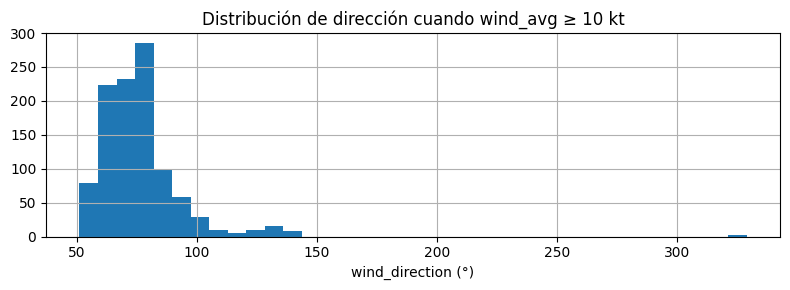

In [370]:
import matplotlib.pyplot as plt

strong_wind = df[df["wind_avg"] >= 10]["wind_direction"].dropna()
print(f"Registros con wind_avg ≥ 10: {len(strong_wind)}")
print(strong_wind.describe().round(2))

fig, ax = plt.subplots(figsize=(8, 3))
strong_wind.hist(bins=36, ax=ax)
ax.set_xlabel("wind_direction (°)")
ax.set_title("Distribución de dirección cuando wind_avg ≥ 10 kt")
plt.tight_layout()

#### Estrategia de imputación

- **`wind_min`**: descartada (100% NaN).
- **Huecos cortos (≤ 6 h)** en variables continuas: interpolación lineal temporal (`limit=6`).
- **Huecos largos (> 6 h)**: corresponden a períodos offline de la estación — se dejan como NaN y se excluyen de las ventanas de entrenamiento.
- **`wind_direction`**:
  - Si `wind_avg ≥ 10` y dirección es NaN → se imputa con la dirección dominante del régimen fuerte (prior físico).
  - Restante: forward-fill limitado a 6 h (viento débil, dirección poco relevante).

In [371]:
df.drop(columns=["wind_min"], inplace=True)

dominant_dir = df[df["wind_avg"] >= 10]["wind_direction"].dropna().mode()[0]
print(f"Dirección dominante (wind_avg ≥ 10): {dominant_dir}°")

for col in ["wind_avg", "wind_max", "temperature", "rh", "mslp", "gustiness"]:
    df[col] = df[col].interpolate(method="time", limit=6)

mask_strong_nan = (df["wind_avg"] >= 10) & df["wind_direction"].isna()
df.loc[mask_strong_nan, "wind_direction"] = dominant_dir
df["wind_direction"] = df["wind_direction"].ffill(limit=6)

print("\nNaN restantes (huecos offline > 6h):")
print(df.isna().sum()[df.isna().sum() > 0])

Dirección dominante (wind_avg ≥ 10): 77.0°

NaN restantes (huecos offline > 6h):
wind_avg          231
wind_max          231
wind_direction    231
temperature       231
rh                231
mslp              231
gustiness         231
dtype: int64


### 4.d) Tipos de Datos, Variables endogenas y exogenas

In [372]:
df.dtypes

wind_avg          float64
wind_max          float64
wind_direction    float64
temperature       float64
rh                float64
mslp              float64
gustiness         float64
dtype: object

Todas las variables son `float64` (numéricas continuas).

En el marco del pronóstico, la única variable **endógena** del modelo es **`wind_avg`** — la que el modelo predice a partir de su propia dinámica. Las demás (`wind_max`, `wind_direction`, `gustiness`, `temperature`, `rh`, `mslp`) son **exógenas**: no son pronosticadas por el modelo y pueden actuar como predictores, siempre que sus valores sean conocidos o pronosticados independientemente al momento del pronóstico (evitando *data leakage*).

### 4.e) Descomposición estacional

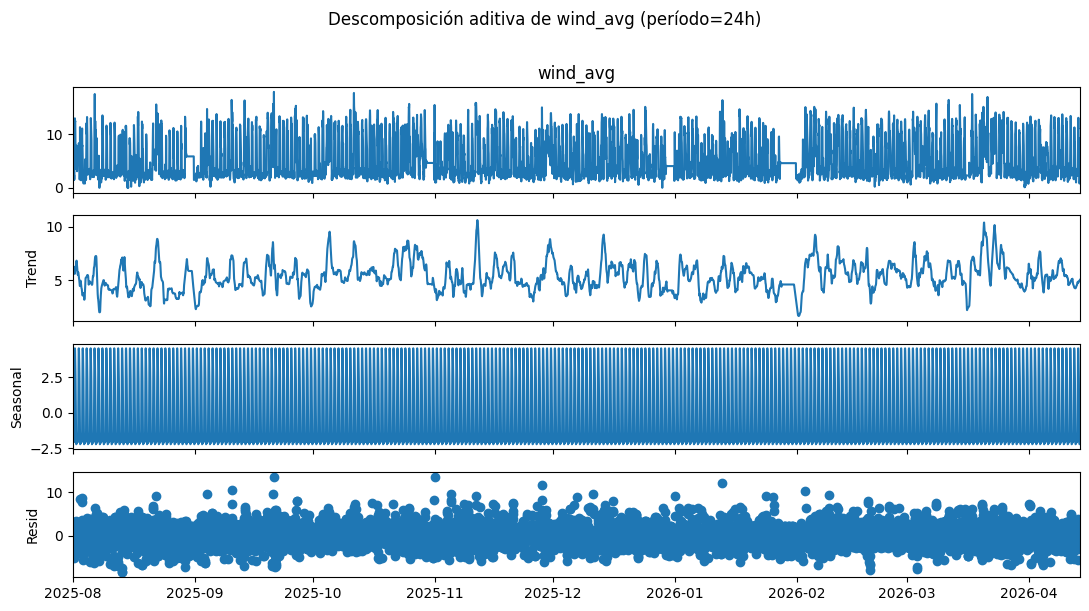

In [373]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

wind_filled = df["wind_avg"].ffill().bfill()

sd = seasonal_decompose(
    wind_filled, model="additive", period=24, extrapolate_trend="freq"
)
fig = sd.plot()
fig.set_size_inches(11, 6)
plt.suptitle("Descomposición aditiva de wind_avg (período=24h)", y=1.01)
plt.tight_layout()

- **Tendencia**: no plana dentro del período observado. La intensidad es menor al inicio (agosto 2025) y mayor hacia los meses centrales del registro (primavera–verano austral). Los extremos están extrapolados (`extrapolate_trend="freq"`), por lo que no interpretamos la tendencia más allá del rango medido y evitamos conclusiones climatológicas con 8.5 meses de datos.
- **Estacionalidad**: componente diaria muy limpia y regular (±2.5 kt). Máximos durante el día y mínimos de madrugada.
- **Residuo**: disperso entre 2 y 5 kt con outliers, conserva cierta estructura → no es ruido blanco puro (ver 4.f).

### 4.f) Estacionariedad y extracción de residuos estacionarios

In [374]:
from statsmodels.tsa.stattools import adfuller

period = 24

print("--- Serie original (wind_avg) ---")
ADF_result = adfuller(df["wind_avg"].dropna())
print(f"ADF Statistic: {ADF_result[0]:.3f}")
print(f"p-value: {ADF_result[1]:.3e}")
print("Critical Values:")
for key, value in ADF_result[4].items():
    print(f"   {key}: {value:.3f}")

print()

print("--- Residuo de la descomposición ---")
ADF_result = adfuller(sd.resid[period:-period].dropna())
print(f"ADF Statistic: {ADF_result[0]:.3f}")
print(f"p-value: {ADF_result[1]:.3e}")
print("Critical Values:")
for key, value in ADF_result[4].items():
    print(f"   {key}: {value:.3f}")

--- Serie original (wind_avg) ---
ADF Statistic: -11.532
p-value: 3.812e-21
Critical Values:
   1%: -3.431
   5%: -2.862
   10%: -2.567

--- Residuo de la descomposición ---
ADF Statistic: -23.396
p-value: 0.000e+00
Critical Values:
   1%: -3.431
   5%: -2.862
   10%: -2.567


La prueba ADF evalúa:
- **H₀**: la serie tiene raíz unitaria (no estacionaria por raíz unitaria).
- **H₁**: no hay raíz unitaria.

**Serie original**: ADF Statistic (-11.53) << valor crítico al 1% (-3.43), p-value ≈ 0 → se rechaza H₀ → **no hay raíz unitaria**. Sin embargo, la serie presenta estacionalidad determinística diaria (ver 4.e, 4.h), por lo que su media depende de la hora del día y **no es débilmente estacionaria en sentido estricto**.

**Residuo** de la descomposición: ADF Statistic (-23.40) refuerza el rechazo de H₀ → el residuo es **estacionario** una vez removido el ciclo diario.

Conclusión: no es necesario diferenciar la serie (no hay raíz unitaria), pero el modelado debe incorporar explícita o implícitamente el ciclo estacional de 24h.

### 4.g) Autocorrelación y autocorrelacion parcial

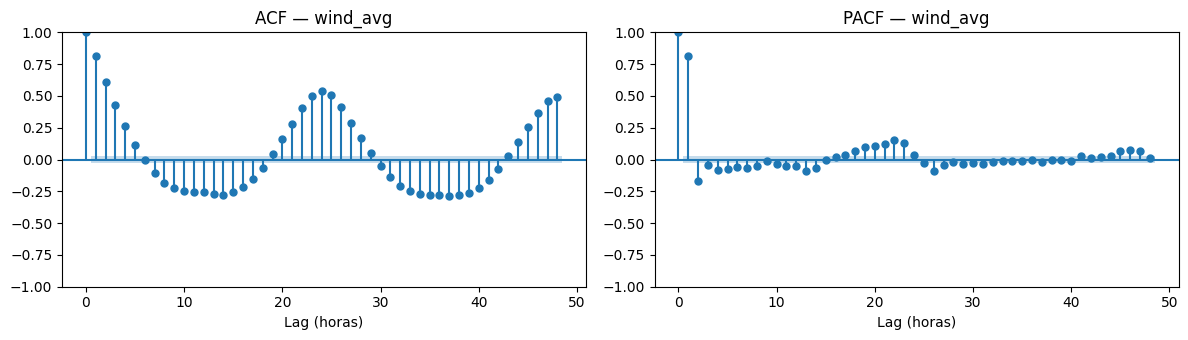

In [375]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

plot_acf(df["wind_avg"].dropna(), lags=48, bartlett_confint=False, ax=axes[0])
axes[0].set_title("ACF — wind_avg")
axes[0].set_xlabel("Lag (horas)")

plot_pacf(df["wind_avg"].dropna(), lags=48, ax=axes[1])
axes[1].set_title("PACF — wind_avg")
axes[1].set_xlabel("Lag (horas)")

plt.tight_layout()

- La ACF cae lentamente y presenta picos pronunciados en los lags 24 y 48, confirmando la **estacionalidad diaria**.
- La PACF cae abruptamente luego del lag 1 (≈0.85) y se mantiene dentro de las bandas de error desde el lag 3.

Un AR(1) puro tendría ACF con decaimiento geométrico sin picos estacionales. El patrón observado (decaimiento lento + picos en 24/48 + PACF cortada en lag 1) es consistente con un **AR(1) más una componente estacional de período 24**, coherente con la descomposición de 4.e. Esto sugiere que el modelo debe incluir explícita o implícitamente el término estacional, no solo lags consecutivos.

### 4.h) Período entre registros y espectro de potencias

Período entre registros: 1 hora (Δt = 1h). Nyquist: 12 ciclos/día.
Varianza: 14.0342  |  Parseval: 14.0342


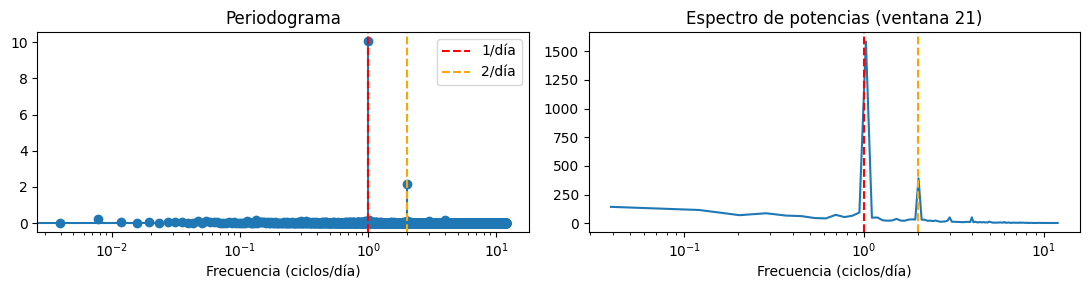

In [376]:
import numpy as np
import matplotlib.pyplot as plt

wind_filled = df["wind_avg"].ffill().bfill()
wind_centered = wind_filled - wind_filled.mean()
NT = len(wind_centered)

wind_f = np.fft.rfft(wind_centered.values)
armonics = np.arange(0, len(wind_f))
wind_f_adj = wind_f * 2 / NT
sqamp = np.real(wind_f_adj) ** 2 + np.imag(wind_f_adj) ** 2

print(f"Período entre registros: 1 hora (Δt = 1h). Nyquist: 12 ciclos/día.")
print(f"Varianza: {np.var(wind_centered):.4f}  |  Parseval: {0.5*np.sum(sqamp):.4f}")

freqs_per_day = armonics * 24 / NT

mw = 10
weights = np.ones(2 * mw + 1)
ps = 0.5 * np.convolve(NT * sqamp, weights, mode="same") / (2 * mw + 1)
ps = ps[mw :: 2 * mw + 1]
fs = armonics[mw :: 2 * mw + 1] * 24 / NT

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].stem(freqs_per_day, sqamp, markerfmt="C0o", basefmt="C0-", linefmt="C0-")
axes[0].set_xscale("log")
axes[0].set_xlabel("Frecuencia (ciclos/día)")
axes[0].set_title("Periodograma")
axes[0].axvline(x=1, color="r", linestyle="--", label="1/día")
axes[0].axvline(x=2, color="orange", linestyle="--", label="2/día")
axes[0].legend(loc="upper right")

axes[1].plot(fs, ps)
axes[1].set_xscale("log")
axes[1].set_xlabel("Frecuencia (ciclos/día)")
axes[1].set_title(f"Espectro de potencias (ventana {2*mw+1})")
axes[1].axvline(x=1, color="r", linestyle="--")
axes[1].axvline(x=2, color="orange", linestyle="--")

plt.tight_layout()

El período entre registros es de **1 hora** (Nyquist = 12 ciclos/día). La identidad de Parseval se verifica (varianza = 14.03 en ambos dominios).

- **Pico dominante en 1 ciclo/día (24h)**: concentra la mayor parte de la varianza — ciclo térmico diario.
- **Armónico en 2 ciclos/día (12h)**: presente pero ~5× menos potente.
- **Fondo de baja frecuencia**: variabilidad sinóptica de multi-días.

La variabilidad de `wind_avg` está dominada por el ciclo diario de 24h, coherente con el viento térmico del embalse.

## 5. Modelo de regresión

Se propone una **regresión lineal** con lags como modelo inicial:
- La PACF mostró dependencia dominantemente AR(1).
- Linealidad como primera hipótesis razonable, comparable contra línea de base.
- 24 lags (ventana de 24h) permiten capturar corto plazo y ciclo diario.

Enfoque de **pronóstico directo**: un sub-modelo por cada paso del horizonte de 12h. Líneas de base: **persistencia** (repite último valor) y **media** (predice la media de entrenamiento). Validación con `TimeSeriesSplit` (3 folds).

In [377]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

pasos = 24
avance = 12

wind = df["wind_avg"]

X = pd.DataFrame({"Lag_0": wind})
for i in range(1, pasos + 1):
    X[f"Lag_{i}"] = wind.shift(i)

for i in range(1, avance + 1):
    X[f"Adv_{i}"] = wind.shift(-i)

X = X.dropna()
print(f"Dataset: {X.shape[0]} filas × {X.shape[1]} columnas")
X.head(3)

Dataset: 5662 filas × 37 columnas


,Lag_0,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,Lag_6,Lag_7,Lag_8,Lag_9,...,Adv_3,Adv_4,Adv_5,Adv_6,Adv_7,Adv_8,Adv_9,Adv_10,Adv_11,Adv_12
datetime,,,,,,,,,,,,,,,,,,,,,
2025-08-02 00:00:00,5.25,5.20,7.90,6.05,4.30,4.60,3.6,7.85,10.05,12.50,...,4.2,6.0,6.30,5.80,5.45,5.20,5.05,5.10,7.10,7.65
2025-08-02 01:00:00,5.85,5.25,5.20,7.90,6.05,4.30,4.6,3.60,7.85,10.05,...,6.0,6.3,5.80,5.45,5.20,5.05,5.10,7.10,7.65,8.35
2025-08-02 02:00:00,3.10,5.85,5.25,5.20,7.90,6.05,4.3,4.60,3.60,7.85,...,6.3,5.8,5.45,5.20,5.05,5.10,7.10,7.65,8.35,7.25


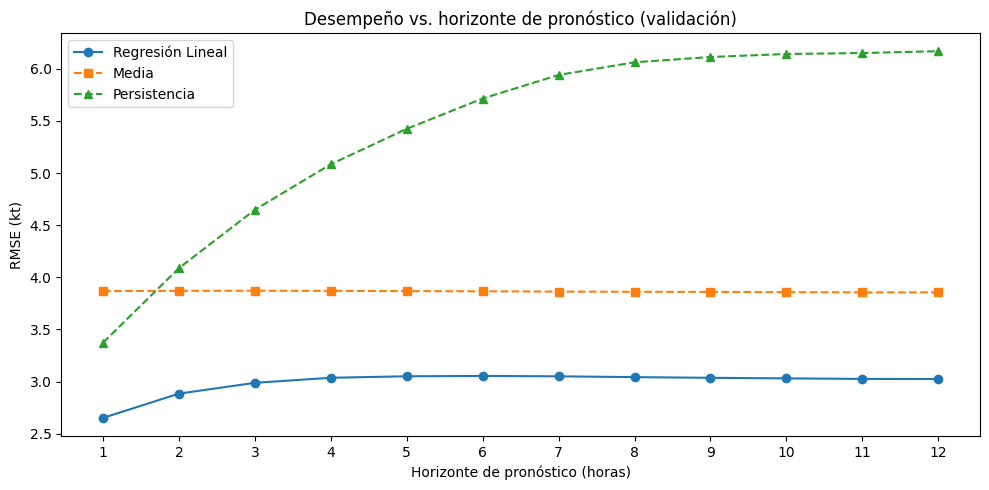

In [378]:
class LastValueEstimator(RegressorMixin, BaseEstimator):
    def fit(self, X, y=None):
        self.is_fitted_ = True
        return self

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            return X.iloc[:, 0].values  # Lag_1 = último valor observado
        return X[:, 0]


class MeanEstimator(RegressorMixin, BaseEstimator):
    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            self.mean_ = X.iloc[:, 0].mean()
        else:
            self.mean_ = X[:, 0].mean()
        self.is_fitted_ = True
        return self

    def predict(self, X):
        return np.repeat(self.mean_, X.shape[0])


tscv = TimeSeriesSplit(n_splits=3)
lr = LinearRegression()
me = MeanEstimator()
lv = LastValueEstimator()

train_rmse_adv = np.empty(shape=[0, 3])
test_rmse_adv = np.empty(shape=[0, 3])

for adv in range(avance):
    train_rmse = np.array([])
    test_rmse = np.array([])
    for train, test in tscv.split(X):
        X_lags_train = X.iloc[train, 1 : pasos + 1]  # Lag_1 .. Lag_24
        y_train = X.iloc[train, pasos + 1 + adv]  # Adv_(adv+1)
        X_lags_test = X.iloc[test, 1 : pasos + 1]
        y_test = X.iloc[test, pasos + 1 + adv]

        for model in [lr, me, lv]:
            model.fit(X_lags_train, y_train)
            train_rmse = np.append(
                train_rmse,
                root_mean_squared_error(y_train, model.predict(X_lags_train)),
            )
            test_rmse = np.append(
                test_rmse, root_mean_squared_error(y_test, model.predict(X_lags_test))
            )

    train_rmse_adv = np.append(
        train_rmse_adv,
        [
            [
                np.mean(train_rmse[0::3]),
                np.mean(train_rmse[1::3]),
                np.mean(train_rmse[2::3]),
            ]
        ],
        axis=0,
    )
    test_rmse_adv = np.append(
        test_rmse_adv,
        [
            [
                np.mean(test_rmse[0::3]),
                np.mean(test_rmse[1::3]),
                np.mean(test_rmse[2::3]),
            ]
        ],
        axis=0,
    )

horizons = np.arange(1, avance + 1)
plt.figure(figsize=(10, 5))
plt.plot(horizons, test_rmse_adv[:, 0], "o-", label="Regresión Lineal")
plt.plot(horizons, test_rmse_adv[:, 1], "s--", label="Media")
plt.plot(horizons, test_rmse_adv[:, 2], "^--", label="Persistencia")
plt.xlabel("Horizonte de pronóstico (horas)")
plt.ylabel("RMSE (kt)")
plt.title("Desempeño vs. horizonte de pronóstico (validación)")
plt.xticks(horizons)
plt.legend()
plt.tight_layout()

In [379]:
# Métricas detalladas para el último fold, horizonte h=12
train_idx, test_idx = list(tscv.split(X))[-1]
X_lags_train = X.iloc[train_idx, 1 : pasos + 1]
y_train = X.iloc[train_idx, pasos + avance]
X_lags_test = X.iloc[test_idx, 1 : pasos + 1]
y_test = X.iloc[test_idx, pasos + avance]

lr.fit(X_lags_train, y_train)
y_pred = lr.predict(X_lags_test)

print(f"=== Regresión Lineal — horizonte h=12h (último fold) ===")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.3f} kt")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.3f} kt")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")

print(f"\n=== Persistencia — horizonte h=12h ===")
y_pers = X_lags_test.iloc[:, 0].values
print(f"RMSE: {root_mean_squared_error(y_test, y_pers):.3f} kt")
print(f"MAE:  {mean_absolute_error(y_test, y_pers):.3f} kt")
print(f"R²:   {r2_score(y_test, y_pers):.3f}")

=== Regresión Lineal — horizonte h=12h (último fold) ===
RMSE: 2.977 kt
MAE:  2.247 kt
R²:   0.440

=== Persistencia — horizonte h=12h ===
RMSE: 6.467 kt
MAE:  5.419 kt
R²:   -1.641


| Modelo | RMSE (kt) | MAE (kt) | R² |
|---|---|---|---|
| Regresión Lineal | 2.98 | 2.25 | 0.44 |
| Persistencia | 6.47 | 5.42 | -1.64 |

La regresión lineal supera ampliamente a la persistencia en h=12h. El R² negativo de persistencia indica que predecir el último valor es peor que predecir la media — razonable para 12h donde el régimen pudo cambiar. La LR explica el 44% de la varianza sin features exógenas ni encodings del ciclo horario — margen claro de mejora para el TP final incorporando temperatura, presión y encoding horario.